EXPLORATORY ANALYSIS OF BRCA1 AND TP53 TUMOUR DATA

Tools used - Python (pandas , numpy , matplotlib / seaborn )
Dataset- cbio portal for cancer genomics
Breast invasive Carcinoma (TCGA, Pan Cancer Atlas)

MOUNTING GOOGLE DRIVE TO GOOGLE COLAB

LOADING THE DATASET

In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/cancer mutation project/data_mutations.txt"
df=pd.read_csv(file_path,sep="\t")
df.head()

/tmp/ipython-input-667118180.py:3: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(file_path,sep="\t")


,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,SYMBOL_SOURCE,TREMBL,TSL,UNIPARC,VARIANT_CLASS,all_effects,cDNA_position,n_depth,t_depth,Annotation_Status
0,GATA3,2625.0,.,GRCh37,10,8115874,8115875,+,frameshift_variant,Frame_Shift_Ins,...,HGNC,.,.,UPI000002AA34,insertion,"GATA3,frameshift_variant,p.Pro408AlafsTer99,EN...",1791-1792,26,44,SUCCESS
1,MALAT1,378938.0,.,GRCh37,11,65272906,65272908,+,non_coding_transcript_exon_variant,RNA,...,HGNC,.,.,.,deletion,"MALAT1,non_coding_transcript_exon_variant,,ENS...",7674-7676,139,78,SUCCESS
2,CD248,57124.0,.,GRCh37,11,66082467,66082467,+,missense_variant,Missense_Mutation,...,HGNC,.,.,UPI0000049803,SNV,"CD248,missense_variant,p.Glu678Lys,ENST0000031...",2049,57,69,SUCCESS
3,NAALAD2,10003.0,.,GRCh37,11,89896900,89896900,+,intron_variant,Intron,...,HGNC,"E9PJ53_HUMAN,E9PII2_HUMAN",.,UPI0000031A85,SNV,"NAALAD2,missense_variant,p.Glu372Lys,ENST00000...",.,65,49,SUCCESS
4,CNPY2,10330.0,.,GRCh37,12,56709872,56709872,+,5_prime_UTR_variant,5'UTR,...,HGNC,"H0YI18_HUMAN,F8W1K5_HUMAN,F8VXJ7_HUMAN",.,UPI000004C630,SNV,"CNPY2,5_prime_UTR_variant,,ENST00000273308,;CN...",249,49,27,SUCCESS


**BRCA1 MUTATION ANALYSIS**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130495 entries, 0 to 130494
Columns: 111 entries, Hugo_Symbol to Annotation_Status
dtypes: float64(3), int64(9), object(99)
memory usage: 110.5+ MB


Each row 130494 are mutation entries.
Each column 111 are detailed annotations for each mutations.


The above datset contains somatic mutations from multiple genes across breast cancer sample . The dataset is filtered specifically to extract BRCA1 gene , which allows identification of mutation frequency , mutation types and hotspot regions within single cancer related genes.BRCA1 is a tumour suppressing gene , mutations in this gene highly leads to breast and ovarian cancer .

In [ ]:
brca1_df = df[df['Hugo_Symbol'] == 'BRCA1']
print("Total BRCA1 Mutations:",brca1_df.shape[0])
brca1_df.head()

Total BRCA1 Mutations: 30


,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,SYMBOL_SOURCE,TREMBL,TSL,UNIPARC,VARIANT_CLASS,all_effects,cDNA_position,n_depth,t_depth,Annotation_Status
1433,BRCA1,672.0,.,GRCh37,17,41244748,41244748,+,stop_gained,Nonsense_Mutation,...,HGNC,"Q9UE29_HUMAN,Q9NQR3_HUMAN,Q92897_HUMAN,Q7KYU6_...",.,UPI0000E0360B,SNV,"BRCA1,stop_gained,p.Gln934Ter,ENST00000346315,...",3032,120,205,SUCCESS
1596,BRCA1,672.0,.,GRCh37,17,41276089,41276089,+,missense_variant,Missense_Mutation,...,HGNC,"Q9UE29_HUMAN,Q9NQR3_HUMAN,Q92897_HUMAN,Q7KYU6_...",.,UPI0000E0360B,SNV,"BRCA1,missense_variant,p.Glu9Gln,ENST000003529...",257,56,35,SUCCESS
1859,BRCA1,672.0,.,GRCh37,17,41245985,41245985,+,synonymous_variant,Silent,...,HGNC,"Q9UE29_HUMAN,Q9NQR3_HUMAN,Q92897_HUMAN,Q7KYU6_...",.,UPI0000E0360B,SNV,"BRCA1,synonymous_variant,p.%3D,ENST00000470026...",1795,67,150,SUCCESS
2124,BRCA1,672.0,.,GRCh37,17,41276033,41276033,+,splice_donor_variant,Splice_Site,...,HGNC,"Q9UE29_HUMAN,Q9NQR3_HUMAN,Q92897_HUMAN,Q7KYU6_...",.,UPI0000E0360B,SNV,"BRCA1,splice_donor_variant,,ENST00000352993,;B...",.,88,124,SUCCESS
8955,BRCA1,672.0,.,GRCh37,17,41245390,41245390,+,stop_gained,Nonsense_Mutation,...,HGNC,"Q9UE29_HUMAN,Q9NQR3_HUMAN,Q92897_HUMAN,Q7KYU6_...",.,UPI0000E0360B,SNV,"BRCA1,stop_gained,p.Glu720Ter,ENST00000346315,...",2390,80,41,SUCCESS


Somatic mutations can be classified based on their functional impact on the protein sequence. Common mutation types include missense, nonsense, frameshift and splice site mutation . In this step brca1 mutations were categorized using the Variant_classification feild to identify the most frequent type of mutation types observed in brast cancer types.

Missense mutation ---> change in amino acid ---> altered protein function
Nonsense mutation ---> premature stop codon ---> turncated protein
Frameshift mutation ---> several functional disruptions

In [ ]:
mutation_type_counts = brca1_df['Variant_Classification'].value_counts()
print(mutation_type_counts)

Variant_Classification
Missense_Mutation    13
Nonsense_Mutation     6
Silent                3
Frame_Shift_Del       3
Splice_Site           2
In_Frame_Del          2
Frame_Shift_Ins       1
Name: count, dtype: int64


Missense mutation are the most frequent type of mutation observed in BRCA1 gene followed by nonsense and frameshift mutations . This suggests that alterations affecting protein structure and function are common in breast cancer associated BRCA1 gene

VISUALIZATION OF BRCA1 MUTATION TYPE DISTRIBUTION

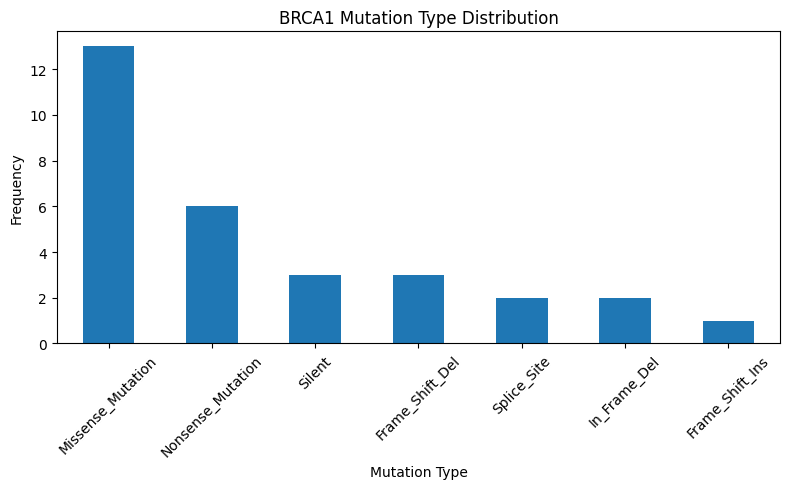

In [ ]:
import matplotlib.pyplot as plt

mutation_type_counts.plot(kind='bar', figsize=(8,5))
plt.title("BRCA1 Mutation Type Distribution")
plt.xlabel("Mutation Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


MUTATION HOTSPOT ANALYSIS
Identification of Mutation Hotspots in the BRCA1 Protein

Mutation hotspots refer to specific amino acid positions in a protein that are mutated more frequently than others.
These regions are often functionally important and may play a critical role in cancer development.
In this analysis, mutation hotspot regions in the BRCA1 protein were identified by examining the frequency of mutations across protein positions

In [ ]:

protein_pos = brca1_df['Protein_position'].dropna().astype(str)
protein_pos_clean = protein_pos.str.extract(r'^(\d+)')[0]
protein_pos_clean = pd.to_numeric(protein_pos_clean, errors='coerce')
protein_pos_clean = protein_pos_clean[(protein_pos_clean > 0) & (protein_pos_clean <= 1863)]
protein_pos_clean.head()


,0
1433,934
1596,9
1859,521
2124,27
8955,720


In [ ]:
hotspots=protein_pos_clean.value_counts()
hotspots.head(10)

,count
0,
934,1
9,1
521,1
27,1
720,1
687,1
903,1
272,1
1483,1


The hotspot analysis revealed that most BRCA1 mutations occur at unique protein positions, with very few positions showing repeated mutations. This indicates that BRCA1 mutations are widely distributed across the protein sequence rather than being concentrated at specific hotspots. Such a pattern is characteristic of tumor suppressor genes, where loss-of-function mutations occurring at multiple locations can disrupt protein activity and contribute to cancer development.

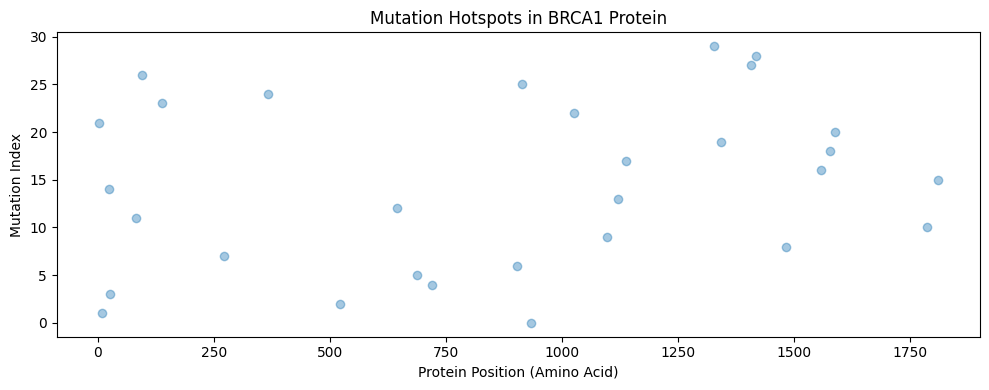

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(protein_pos_clean, range(len(protein_pos_clean)), alpha=0.4)
plt.xlabel("Protein Position (Amino Acid)")
plt.ylabel("Mutation Index")
plt.title("Mutation Hotspots in BRCA1 Protein")
plt.tight_layout()
plt.show()


The above scatter plot is a mutation hotspot in the  hotspot in BRCA1 gene
X-axis is protein position (amino acid ) in BRCA1
The y-axis is the mutation index (spread dots vertically and prevent overlapping ).
Each dot represents a mutation at a specific protein site.

OBSERAVATIONS
There is no dense vertical cluster of points at a particular amino acid , this means the mutation are spread across the entire protein length. So, BRCA1 does not have any mutation hotspots it occurs at different sites .

**TP53 MUTATION HOTSPOT ANALYSIS**

TP53 is one of the most frequently mutated genes in human cancers and plays a critical role in cell cycle regulation and apoptosis. Unlike BRCA1, TP53 mutations often cluster at specific amino acid positions, particularly within the DNA-binding domain. In this analysis, mutation hotspot regions in the TP53 protein were identified by examining the frequency and distribution of mutations across protein position

In [ ]:
tp53_df = df[df['Hugo_Symbol']== 'TP53']
print("Total TP53 mutations :", tp53_df.shape[0])
print("Shape of TP53 DataFrame:", tp53_df.shape)

Total TP53 mutations : 372
Shape of TP53 DataFrame: (372, 111)


In [ ]:
tp53_pos = tp53_df['Protein_position'].dropna().astype(str)
tp53_pos_clean = tp53_pos.str.extract(r'^(\d+)')[0]
tp53_pos_clean = pd.to_numeric(tp53_pos_clean, errors='coerce')
tp53_pos_clean = tp53_pos_clean[(tp53_pos_clean > 0) & (tp53_pos_clean <= 393)]
tp53_pos_clean.head()


,0
288,183
1600,175
1861,133
2136,220
2408,183


In [ ]:
tp53_hotspots = tp53_pos_clean.value_counts().head(10)
tp53_hotspots


,count
0,
175,23
273,23
220,10
342,10
193,10
248,10
196,8
213,7
179,7


TP53 hotspots occur mostly at DNA binding domain.The clustering of mutations at these positions suggests strong selective pressure favoring alterations that impair tumor suppressor activity.

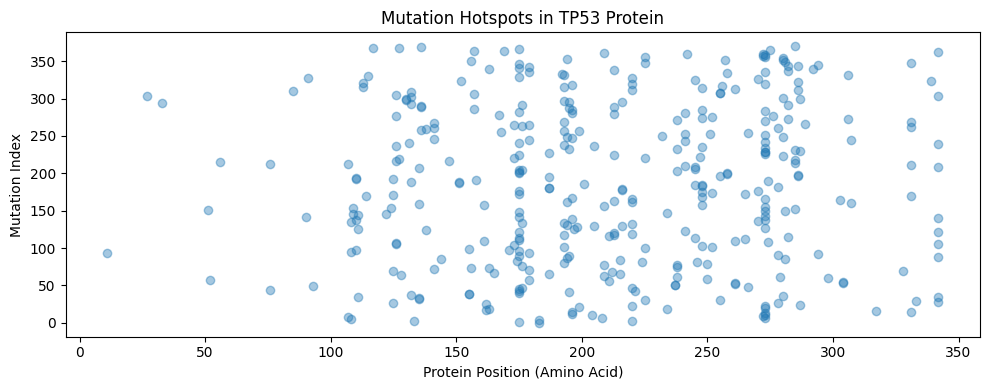

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(tp53_pos_clean, range(len(tp53_pos_clean)), alpha=0.4)
plt.xlabel("Protein Position (Amino Acid)")
plt.ylabel("Mutation Index")
plt.title("Mutation Hotspots in TP53 Protein")
plt.tight_layout()
plt.show()


The above scatter plot is visualization of mutations in TP53 protein . the X-axis is protein position and the Y-axix is just to spread points vertically and not to overlap . Hotspots appear as vertical cluster of dots . There are dense vertical dots around ~175, ~273, ~248, etc. These are classic TP53 hotspots.

Mutations at these residues prevent p53 from binding DNA , disable cell cucle arrest and apoptosis.Provides strong support advantage for cancer.

**CONCLUSION**

In this study, somatic mutation patterns in key cancer-related genes were analyzed using publicly available TCGA breast cancer mutation data. Computational analysis was performed using Python to examine mutation frequency, mutation types, and protein-level mutation distribution in BRCA1 and TP53 genes.
In this analysis distinct mutation patterns between the two genes. BRCA1 mutations were widely distributed across the protein sequence, with no strong hotspot regions observed. This distributed mutation pattern is characteristic of tumor suppressor genes, where loss of function can result from mutations occurring at multiple locations throughout the gene.
In contrast, TP53 showed clear mutation hotspots at specific amino acid positions, particularly within the DNA-binding domain. These recurrent hotspot mutations indicate strong selective pressure for alterations that disrupt p53 tumor suppressor function and promote cancer progression. The presence of such hotspots highlights a dominant-negative or gain-of-function mutation mechanism unique to TP53.
Overall, this study demonstrates how computational analysis of cancer genomics data can reveal biologically meaningful differences in mutation mechanisms between genes. The results emphasize the importance of gene-specific mutation analysis for understanding cancer biology and illustrate the power of bioinformatics approaches in analyzing large-scale genomic datasets without wet-lab experimentation.